# Notebook 05: Tumour Growth Rate Prediction

This notebook predicts **tumour growth rate** (mm³/day) between consecutive MRI timepoints using baseline clinical features and first-timepoint imaging features.

This addresses Aim 2 of the project: *"Create predictive models that forecast tumour evolution trajectories (growth rates, patterns, morphological changes)."*

**Task:** Regression (continuous target), not classification.

**Input:** Clinical + molecular features (available at diagnosis) + first-timepoint imaging statistics from the pre-computed segmentation volumes.

**Target:** Growth rate = (Volume_t1 - Volume_t0) / days_elapsed, in mm³/day.

**Sample:** ~82 patients with at least 2 imaging timepoints.

## Setup

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')

In [5]:
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from scipy import stats

In [6]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

from google.colab import userdata
GLIOMA_DIR = userdata.get('GLIOMA_DIR')
print(f"Glioma directory: {GLIOMA_DIR}")

Mounted at /content/drive/
Glioma directory: drive/MyDrive/Y3 Project/Data/PKG_MU_Glioma_Post


In [7]:
RESULTS_DIR = os.path.join(GLIOMA_DIR, 'growth_rate', 'data')
FIGURES_DIR = os.path.join(GLIOMA_DIR, 'growth_rate', 'figures')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"Results directory: {RESULTS_DIR}")
print(f"Figures directory: {FIGURES_DIR}")

Results directory: drive/MyDrive/Y3 Project/Data/PKG_MU_Glioma_Post/growth_rate/data
Figures directory: drive/MyDrive/Y3 Project/Data/PKG_MU_Glioma_Post/growth_rate/figures


## Load Data

We need two data sources:
1. **Clinical data** (preprocessed from Notebook 01): demographics, molecular markers, tumour characteristics.
2. **Segmentation volumes** (pre-computed by dataset providers): tumour volume and intensity statistics per timepoint.

### Load Clinical Data

In [8]:
preprocessed_dir = os.path.join(GLIOMA_DIR, 'preprocessed')

high_fill_df = pd.read_pickle(os.path.join(preprocessed_dir, 'high_fill_df.pkl'))
X = pd.read_pickle(os.path.join(preprocessed_dir, 'X.pkl'))
y = pd.read_pickle(os.path.join(preprocessed_dir, 'y.pkl'))

print(f"Clinical data loaded: {high_fill_df.shape}")
print(f"X: {X.shape}, y: {y.shape}")

Clinical data loaded: (203, 29)
X: (203, 28), y: (203,)


### Load Segmentation Volumes

The segmentation volumes Excel file contains **four sheets**, each representing a different tumour subregion:

| Sheet | Region | Clinical Meaning |
|-------|--------|------------------|
| Necrotic Tumor Core (Label1) | Dead tissue | Aggressive tumour indicator |
| Tumor Infiltration and Edema | Surrounding oedema | Tumour extent/invasion |
| Enhancing Tumor Core (Label3) | Active tumour | Treatment target |
| Resection Cavity (Label4) | Surgical void | Post-operative status |

**Total tumour volume** at each timepoint is the sum of all subregion volumes. Not all patients have entries in every sheet (e.g. some may have no necrotic core or no resection cavity), so we treat missing subregions as zero volume.

Each sheet contains multiple rows per patient (one per scan timepoint), with pre-extracted volume and intensity statistics.


In [9]:
seg_path = os.path.join(GLIOMA_DIR, 'MU_Glioma_Post_Segmentation_Volumes.xlsx')

# The Excel file has 4 sheets, each representing a different tumour subregion:
#   - Necrotic Tumor Core (Label1): dead tissue within tumour
#   - Tumor Infiltration and Edema: surrounding oedema and infiltration
#   - Enhancing Tumor Core (Label3): active, contrast-enhancing tumour
#   - Resection Cavity (Label4): post-surgical cavity
#
# Total tumour volume = sum of all subregion volumes for each patient-timepoint.
# Not all patients appear in every sheet (e.g. some have no necrotic core).

sheets = [
    ('Necrotic Tumor Core (Label1)', 'necrotic'),
    ('Tumor Infiltration and Edema', 'edema'),
    ('Enhancing Tumor Core (Label3)', 'enhancing'),
    ('Resection Cavity (Label4)', 'cavity')
]

xl = pd.ExcelFile(seg_path)
print(f"Available sheets: {xl.sheet_names}")

all_sheet_dfs = []
for sheet_name, prefix in sheets:
    df_sheet = pd.read_excel(seg_path, sheet_name=sheet_name)
    n_patients = df_sheet['Patient ID'].nunique()
    print(f"\n{sheet_name}: {len(df_sheet)} rows, {n_patients} unique patients")

    # Rename volume column with prefix for clarity before aggregation
    df_sheet = df_sheet.rename(columns={
        'Volume (mm^3)': f'{prefix}_volume',
        'Number Of Voxels': f'{prefix}_voxels',
        'Image mean (brain_t1c)': f'{prefix}_t1c_mean',
        'Image stdev (brain_t1c)': f'{prefix}_t1c_std',
        'Image mean (brain_t1n)': f'{prefix}_t1n_mean',
        'Image stdev (brain_t1n)': f'{prefix}_t1n_std',
        'Image mean (brain_t2f)': f'{prefix}_t2f_mean',
        'Image stdev (brain_t2f)': f'{prefix}_t2f_std',
        'Image mean (brain_t2w)': f'{prefix}_t2w_mean',
        'Image stdev (brain_t2w)': f'{prefix}_t2w_std',
    })
    df_sheet['_sheet'] = prefix
    all_sheet_dfs.append(df_sheet)

# Each sheet has multiple rows per patient (one per timepoint).
# We need to compute TOTAL tumour volume per patient-timepoint by summing
# subregion volumes across sheets.
#
# Strategy: for each sheet, assign a timepoint index (row order within patient),
# then pivot so we can sum volumes across subregions at each timepoint.

print()
print("Computing total tumour volume per patient-timepoint...")
print("-" * 60)

# For each sheet, number the timepoints per patient (0, 1, 2, ...)
for df_sheet in all_sheet_dfs:
    df_sheet['tp_idx'] = df_sheet.groupby('Patient ID').cumcount()

# Collect volume per (Patient ID, tp_idx) from each sheet
volume_frames = []
for df_sheet, (sheet_name, prefix) in zip(all_sheet_dfs, sheets):
    vol_col = f'{prefix}_volume'
    sub = df_sheet[['Patient ID', 'tp_idx', vol_col]].copy()
    volume_frames.append(sub)

# Merge all subregion volumes on (Patient ID, tp_idx)
merged_vols = volume_frames[0]
for vf in volume_frames[1:]:
    merged_vols = merged_vols.merge(vf, on=['Patient ID', 'tp_idx'], how='outer')

# Compute total volume = sum of all subregion volumes (NaN treated as 0)
vol_cols = [f'{prefix}_volume' for _, prefix in sheets]
merged_vols['total_volume'] = merged_vols[vol_cols].fillna(0).sum(axis=1)

print(f"\nTotal volume records: {len(merged_vols)}")
print(f"Unique patients: {merged_vols['Patient ID'].nunique()}")
print(f"\nTimepoints per patient:")
print(merged_vols.groupby('Patient ID')['tp_idx'].max().value_counts().sort_index().rename(
    index=lambda x: f"{x+1} timepoint(s)"))

# Also collect intensity features from the edema sheet (best coverage)
# for use as first-timepoint predictors
edema_df = all_sheet_dfs[1]  # Tumour Infiltration and Edema

# Store for later use
seg_df = merged_vols.copy()


Available sheets: ['Necrotic Tumor Core (Label1)', 'Tumor Infiltration and Edema', 'Enhancing Tumor Core (Label3)', 'Resection Cavity (Label4)']

Necrotic Tumor Core (Label1): 334 rows, 173 unique patients

Tumor Infiltration and Edema: 614 rows, 321 unique patients

Enhancing Tumor Core (Label3): 569 rows, 286 unique patients

Resection Cavity (Label4): 542 rows, 291 unique patients

Computing total tumour volume per patient-timepoint...
------------------------------------------------------------

Total volume records: 617
Unique patients: 324

Timepoints per patient:
tp_idx
1 timepoint(s)    200
2 timepoint(s)     52
3 timepoint(s)     26
4 timepoint(s)     15
5 timepoint(s)     13
6 timepoint(s)     17
8 timepoint(s)      1
Name: count, dtype: int64


## Construct Growth Rate Target

For each patient with at least 2 timepoints, we compute the growth rate between their first two scans.

**Formula:** `growth_rate = (volume_t1 - volume_t0) / days_elapsed`

Units: mm³/day. A positive value means the tumour grew; negative means it shrank (e.g. post-treatment response).

We use only the first pair of timepoints (t0 → t1) to keep the prediction task clean: predict growth from baseline.

In [10]:
# Check how many timepoints each patient has (using the merged total volumes)
tp_counts = seg_df.groupby('Patient ID')['tp_idx'].max() + 1  # tp_idx is 0-based

print(f"Patients with 1 timepoint: {(tp_counts == 1).sum()}")
print(f"Patients with 2+ timepoints: {(tp_counts >= 2).sum()}")
print(f"\nTimepoint distribution:")
print(tp_counts.value_counts().sort_index())


Patients with 1 timepoint: 200
Patients with 2+ timepoints: 124

Timepoint distribution:
tp_idx
1    200
2     52
3     26
4     15
5     13
6     17
8      1
Name: count, dtype: int64


### Extract First Two Timepoints Per Patient

For each patient with 2+ timepoints, we extract the **total tumour volume** (summed across all four subregions) at timepoints 0 and 1. The growth target is the volume difference.

We also extract individual subregion volumes at t0 as features (necrotic, edema, enhancing, cavity), plus intensity statistics from the edema sheet (which has the best patient coverage at 321 unique patients).


In [11]:
# Get patients with at least 2 timepoints
multi_tp_patients = tp_counts[tp_counts >= 2].index.tolist()
print(f"Patients with 2+ timepoints: {len(multi_tp_patients)}")

# Extract first two timepoints per patient using TOTAL tumour volume
growth_records = []

for pid in multi_tp_patients:
    patient_vols = seg_df[seg_df['Patient ID'] == pid].sort_values('tp_idx')

    t0 = patient_vols[patient_vols['tp_idx'] == 0]
    t1 = patient_vols[patient_vols['tp_idx'] == 1]

    if len(t0) == 0 or len(t1) == 0:
        continue

    vol_t0 = t0['total_volume'].values[0]
    vol_t1 = t1['total_volume'].values[0]
    delta_volume = vol_t1 - vol_t0

    # Get first-timepoint imaging features from edema sheet (best coverage)
    edema_t0 = edema_df[(edema_df['Patient ID'] == pid) & (edema_df['tp_idx'] == 0)]

    record = {
        'Patient ID': pid,
        'vol_t0': vol_t0,
        'vol_t1': vol_t1,
        'delta_volume': delta_volume,
    }

    # Add subregion volumes at t0 as features
    for _, prefix in sheets:
        vcol = f'{prefix}_volume'
        t0_sub = seg_df[(seg_df['Patient ID'] == pid) & (seg_df['tp_idx'] == 0)]
        record[f't0_{prefix}_vol'] = t0_sub[vcol].values[0] if vcol in t0_sub.columns and len(t0_sub) > 0 and pd.notna(t0_sub[vcol].values[0]) else 0.0

    # Add intensity features from edema sheet at t0
    if len(edema_t0) > 0:
        record['t0_t1c_mean'] = edema_t0['edema_t1c_mean'].values[0]
        record['t0_t1c_std'] = edema_t0['edema_t1c_std'].values[0]
        record['t0_t1n_mean'] = edema_t0['edema_t1n_mean'].values[0]
        record['t0_t1n_std'] = edema_t0['edema_t1n_std'].values[0]
        record['t0_t2f_mean'] = edema_t0['edema_t2f_mean'].values[0]
        record['t0_t2f_std'] = edema_t0['edema_t2f_std'].values[0]
        record['t0_t2w_mean'] = edema_t0['edema_t2w_mean'].values[0]
        record['t0_t2w_std'] = edema_t0['edema_t2w_std'].values[0]
    else:
        # Patient not in edema sheet; fill with NaN
        for feat in ['t0_t1c_mean', 't0_t1c_std', 't0_t1n_mean', 't0_t1n_std',
                      't0_t2f_mean', 't0_t2f_std', 't0_t2w_mean', 't0_t2w_std']:
            record[feat] = np.nan

    growth_records.append(record)

growth_df = pd.DataFrame(growth_records)
print(f"\nGrowth data constructed: {growth_df.shape}")
print(f"\nTotal volume at t0 statistics:")
print(growth_df['vol_t0'].describe())
print(f"\nDelta volume statistics (total tumour):")
print(growth_df['delta_volume'].describe())
print(f"\nMissing values:")
print(growth_df.isnull().sum()[growth_df.isnull().sum() > 0])

Patients with 2+ timepoints: 124

Growth data constructed: (124, 16)

Total volume at t0 statistics:
count       124.000000
mean      82802.338710
std       57731.074726
min        4035.000000
25%       37460.500000
50%       67466.000000
75%      124913.250000
max      257791.000000
Name: vol_t0, dtype: float64

Delta volume statistics (total tumour):
count       124.000000
mean       1078.419355
std       59691.292710
min     -160366.000000
25%      -29025.500000
50%           0.000000
75%       19545.000000
max      211791.000000
Name: delta_volume, dtype: float64

Missing values:
Series([], dtype: int64)


In [12]:
growth_df.head()

,Patient ID,vol_t0,vol_t1,delta_volume,t0_necrotic_vol,t0_edema_vol,t0_enhancing_vol,t0_cavity_vol,t0_t1c_mean,t0_t1c_std,t0_t1n_mean,t0_t1n_std,t0_t2f_mean,t0_t2f_std,t0_t2w_mean,t0_t2w_std
0,PatientID_0003,84540.0,85818.0,1278.0,6510.0,44251.0,33779.0,0.0,353.094610,19.368804,296.371803,23.638734,427.936617,50.434048,455.942745,72.198390
1,PatientID_0005,139453.0,140311.0,858.0,2946.0,93727.0,42780.0,0.0,396.366261,22.758249,260.544393,86.856273,500.307445,73.222999,542.475826,99.106971
2,PatientID_0006,166060.0,83049.0,-83011.0,289.0,130618.0,2594.0,32559.0,480.454499,52.272928,461.919794,50.122729,495.909582,58.572463,580.630798,115.549675
3,PatientID_0007,48582.0,48109.0,-473.0,0.0,27824.0,7787.0,12971.0,242.640305,27.610877,235.318865,26.929720,405.486114,56.008831,446.548813,85.899901
4,PatientID_0008,87128.0,31276.0,-55852.0,0.0,63795.0,7116.0,16217.0,795.804736,58.301609,338.621425,34.305999,513.265279,76.811628,545.441349,103.907591


### Estimate Days Between Scans

The segmentation volumes file does not include scan dates directly. We attempt to estimate inter-scan intervals from the clinical data columns that contain temporal information.

If exact dates are unavailable, we use the volume change itself (delta_volume in mm³) as the regression target rather than a rate. This is still clinically meaningful: predicting how much a tumour will change between consecutive scans.

In [13]:
# Check if we have any date-related columns in the clinical data
date_cols = [col for col in high_fill_df.columns if 'date' in col.lower() or 'day' in col.lower() or 'time' in col.lower()]
print("Date/time-related columns in clinical data:")
for col in date_cols:
    print(f"  - {col}: {high_fill_df[col].dtype}")
    if high_fill_df[col].dtype in ['float64', 'int64']:
        print(f"    Range: {high_fill_df[col].min():.0f} - {high_fill_df[col].max():.0f}")

Date/time-related columns in clinical data:
  - time to first progression (days): float64
    Range: 4 - 2126
  - number of days from diagnosis to first surgery or procedure: int64
    Range: -81 - 116
  - number of days from diagnosis to date of first progression: float64
    Range: -22 - 2126
  - number of days from diagnosis to 1st mri (timepoint_1): float64
    Range: -58 - 464


In [14]:
# Exact inter-scan intervals are not available in the clinical data.
# We have days-to-first-MRI but not days-to-second-MRI,
# so we cannot compute a rate (mm³/day).
# We use absolute volume change (mm³) as the target instead.
# This is still clinically meaningful: predicting how much a
# tumour's volume will change between consecutive scans.

TARGET_COL = 'delta_volume'

print(f"Target variable: {TARGET_COL}")
print(f"\nTarget distribution:")
print(growth_df[TARGET_COL].describe())
print(f"\nPatients with tumour growth (positive delta): {(growth_df[TARGET_COL] > 0).sum()}")
print(f"Patients with tumour shrinkage (negative delta): {(growth_df[TARGET_COL] < 0).sum()}")
print(f"Patients with no change: {(growth_df[TARGET_COL] == 0).sum()}")

Target variable: delta_volume

Target distribution:
count       124.000000
mean       1078.419355
std       59691.292710
min     -160366.000000
25%      -29025.500000
50%           0.000000
75%       19545.000000
max      211791.000000
Name: delta_volume, dtype: float64

Patients with tumour growth (positive delta): 61
Patients with tumour shrinkage (negative delta): 58
Patients with no change: 5


### Visualise Target Distribution

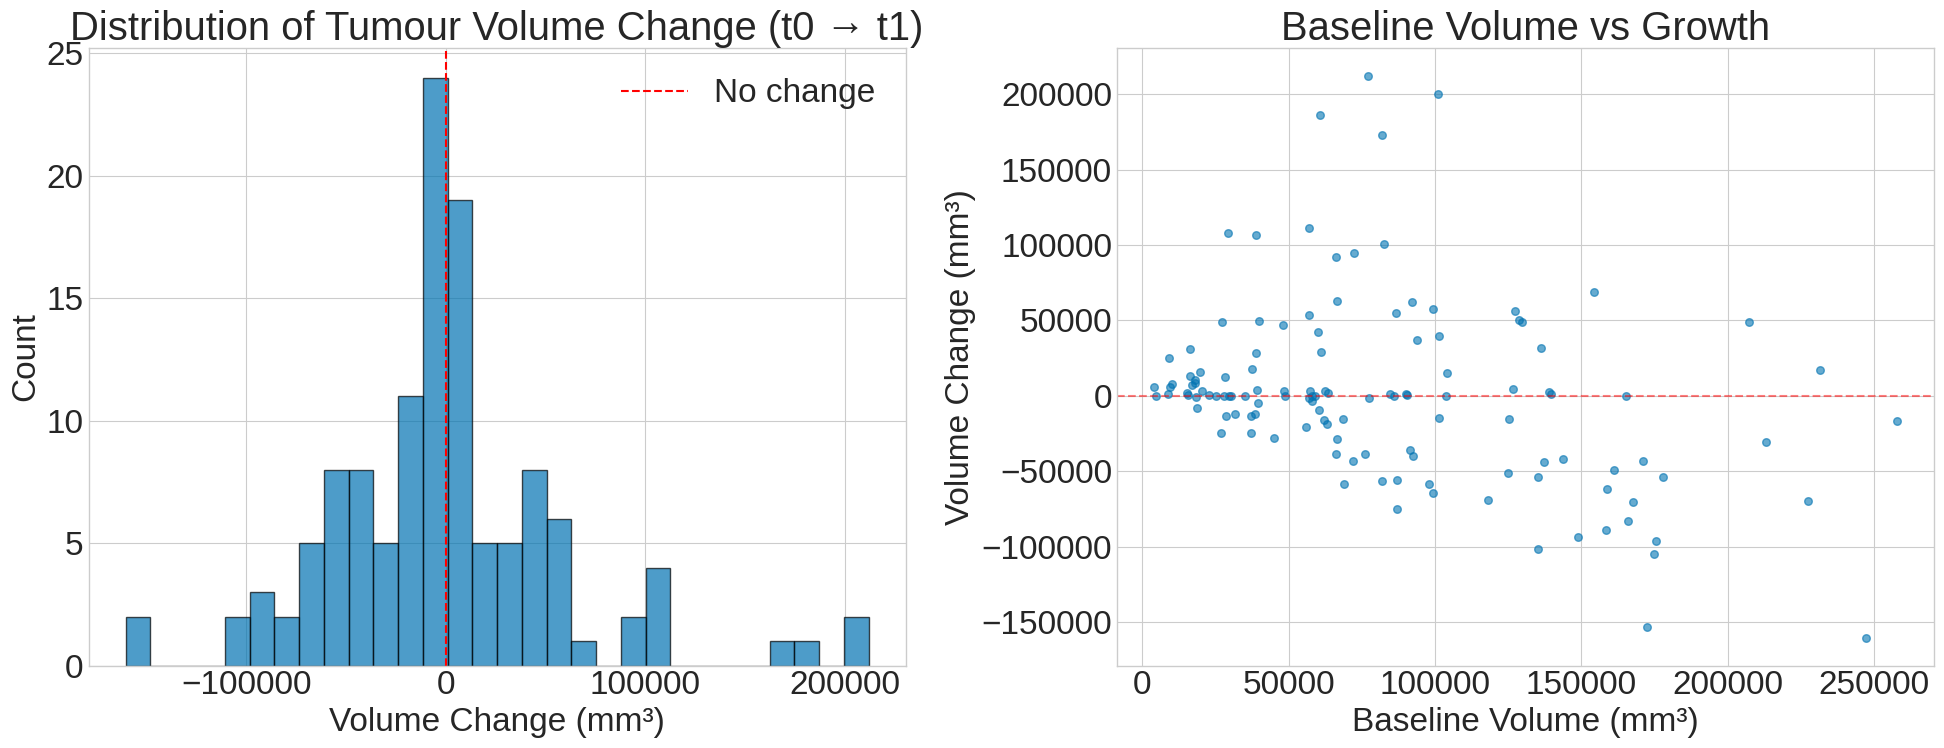

In [15]:
plt.rcParams.update({'font.size': 24})

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Histogram
axes[0].hist(growth_df[TARGET_COL], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', label='No change')
axes[0].set_xlabel('Volume Change (mm³)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Tumour Volume Change (t0 → t1)')
axes[0].legend()

# Baseline volume vs change
axes[1].scatter(growth_df['vol_t0'], growth_df[TARGET_COL], alpha=0.6, s=30)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Baseline Volume (mm³)')
axes[1].set_ylabel('Volume Change (mm³)')
axes[1].set_title('Baseline Volume vs Growth')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_growth_target_distribution.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, '05_growth_target_distribution.pdf'), bbox_inches='tight')
plt.show()

## Merge Clinical and Imaging Features

We merge the first-timepoint imaging features with the clinical feature matrix. The clinical features come from the preprocessed `X` matrix (leakage features already removed in Notebook 02).

We align on Patient ID, keeping only patients present in both datasets.

In [16]:
# We need to align Patient IDs between clinical and growth data
# Check the ID format in both
print("Clinical data ID sample:", high_fill_df.index[:3].tolist() if high_fill_df.index.name else 'Index not named')
print("Growth data ID sample:", growth_df['Patient ID'].iloc[:3].tolist())

# Check if clinical data has patient IDs as index or column
clinical_id_cols = [col for col in high_fill_df.columns if 'patient' in col.lower() or 'id' in col.lower()]
print(f"\nPotential ID columns in clinical data: {clinical_id_cols}")
print(f"Index name: {high_fill_df.index.name}")

Clinical data ID sample: Index not named
Growth data ID sample: ['PatientID_0003', 'PatientID_0005', 'PatientID_0006']

Potential ID columns in clinical data: ['idh1 mutation', 'idh2 mutation']
Index name: None


In [17]:
# The preprocessed X matrix doesn't have Patient_ID (dropped during encoding).
# We need to get Patient IDs from the original clinical data.
# Load the original clinical CSV to get the ID mapping.

MU_GLIOMA_CLINICAL_DATA = os.path.join(GLIOMA_DIR, 'MU_Glioma_Post_ClinicalData_July2025.xlsx')
original_clinical = pd.read_excel(MU_GLIOMA_CLINICAL_DATA, sheet_name='MU Glioma Post')

# Check format
print("Original clinical ID sample:", original_clinical['Patient_ID'].iloc[:3].tolist())
print("Growth data ID sample:", growth_df['Patient ID'].iloc[:3].tolist())

# The original clinical df has same row order as high_fill_df/X
# Add Patient ID back to clinical features
clinical_for_merge = high_fill_df.copy()
clinical_for_merge['Patient_ID'] = original_clinical['Patient_ID'].values
clinical_for_merge = clinical_for_merge.set_index('Patient_ID')

clean_feature_cols = X.columns.tolist()
print(f"Clean clinical features: {len(clean_feature_cols)}")

Original clinical ID sample: ['PatientID_0003', 'PatientID_0004', 'PatientID_0005']
Growth data ID sample: ['PatientID_0003', 'PatientID_0005', 'PatientID_0006']
Clean clinical features: 28


In [18]:
# Build the combined feature matrix
# Start with growth_df (has Patient ID + imaging features + target)
# Add clinical features by matching Patient ID

imaging_feature_cols = [
    'vol_t0',
    't0_necrotic_vol', 't0_edema_vol', 't0_enhancing_vol', 't0_cavity_vol',
    't0_t1c_mean', 't0_t1c_std',
    't0_t1n_mean', 't0_t1n_std', 't0_t2f_mean',
    't0_t2f_std', 't0_t2w_mean', 't0_t2w_std'
]

# Attempt merge using left_on and right_on for different column names
growth_with_clinical = growth_df.merge(
    clinical_for_merge[clean_feature_cols].reset_index(),
    left_on='Patient ID',
    right_on='Patient_ID',
    how='inner'
)

# Fill NaN imaging features with 0 (missing subregion = no volume for that region)
for col in imaging_feature_cols:
    if col in growth_with_clinical.columns:
        growth_with_clinical[col] = growth_with_clinical[col].fillna(0)

print(f"Merged dataset: {growth_with_clinical.shape}")
print(f"Patients retained: {len(growth_with_clinical)} / {len(growth_df)} (from growth data)")
print(f"Lost to ID mismatch: {len(growth_df) - len(growth_with_clinical)}")


Merged dataset: (105, 45)
Patients retained: 105 / 124 (from growth data)
Lost to ID mismatch: 19


In [19]:
# Define feature sets for comparison
all_feature_cols = clean_feature_cols + imaging_feature_cols

X_combined = growth_with_clinical[all_feature_cols].copy()
X_clinical_only = growth_with_clinical[clean_feature_cols].copy()
X_imaging_only = growth_with_clinical[imaging_feature_cols].copy()
y_growth = growth_with_clinical[TARGET_COL].copy()

print(f"Feature sets:")
print(f"  Clinical only: {X_clinical_only.shape[1]} features")
print(f"  Imaging only: {X_imaging_only.shape[1]} features")
print(f"  Combined: {X_combined.shape[1]} features")
print(f"  Target: {y_growth.shape[0]} samples")

Feature sets:
  Clinical only: 28 features
  Imaging only: 13 features
  Combined: 41 features
  Target: 105 samples


In [20]:
# Remove leakage features that encode future outcomes
# These were identified in Notebook 02 but may persist in the preprocessed data
leakage_features = [
    'second progression/recurrence',
    'type of 2nd progression',
    'time to first progression (days)',
    'number of days from diagnosis to date of first progression',
    'number of days from diagnosis to first surgery or procedure',
    'progression',
    'type of 1st progression'
]

if leakage_features:
    print(f"Removing {len(leakage_features)} leakage features:")
    for f in leakage_features:
        print(f"  - {f}")

    X_combined = X_combined.drop(columns=leakage_features)
    X_clinical_only = X_clinical_only.drop(columns=[f for f in leakage_features if f in X_clinical_only.columns])
    clean_feature_cols = [c for c in clean_feature_cols if c not in leakage_features]

    print(f"\nUpdated feature sets:")
    print(f"  Clinical only: {X_clinical_only.shape[1]} features")
    print(f"  Imaging only: {X_imaging_only.shape[1]} features")
    print(f"  Combined: {X_combined.shape[1]} features")
else:
    print("No leakage features found.")

Removing 7 leakage features:
  - second progression/recurrence
  - type of 2nd progression
  - time to first progression (days)
  - number of days from diagnosis to date of first progression
  - number of days from diagnosis to first surgery or procedure
  - progression
  - type of 1st progression

Updated feature sets:
  Clinical only: 21 features
  Imaging only: 13 features
  Combined: 34 features


## Handle Outliers

Growth rate data may contain extreme outliers (e.g. very large tumour resections appearing as massive negative changes). We inspect the distribution and clip or remove outliers if necessary.

In [21]:
# Check for extreme values
q01 = y_growth.quantile(0.01)
q99 = y_growth.quantile(0.99)
iqr = y_growth.quantile(0.75) - y_growth.quantile(0.25)
lower_fence = y_growth.quantile(0.25) - 3 * iqr
upper_fence = y_growth.quantile(0.75) + 3 * iqr

outliers = (y_growth < lower_fence) | (y_growth > upper_fence)
print(f"Outlier detection (3x IQR):")
print(f"  Lower fence: {lower_fence:.0f} mm³")
print(f"  Upper fence: {upper_fence:.0f} mm³")
print(f"  Outliers: {outliers.sum()} ({outliers.mean()*100:.1f}%)")

if outliers.sum() > 0:
    print(f"\nOutlier values:")
    print(y_growth[outliers].values)

Outlier detection (3x IQR):
  Lower fence: -253499 mm³
  Upper fence: 245111 mm³
  Outliers: 0 (0.0%)


In [22]:
# Decision: clip extreme outliers rather than removing them to preserve sample size
# This is important given we already have a small dataset (~82 patients)
if outliers.sum() > 0:
    y_growth_clipped = y_growth.clip(lower=lower_fence, upper=upper_fence)
    print(f"Clipped {outliers.sum()} outliers to [{lower_fence:.0f}, {upper_fence:.0f}]")
else:
    y_growth_clipped = y_growth.copy()
    print("No outliers detected; using original values.")

No outliers detected; using original values.


## Model Training and Evaluation

We train regression models to predict tumour volume change from baseline features. Given the small sample size (~82 patients), we use **Repeated K-Fold cross-validation** (5 folds, 5 repeats = 25 evaluations) to get robust performance estimates.

We compare:
1. **Linear Regression** (baseline)
2. **Ridge Regression** (L2 regularisation; better for small datasets with correlated features)
3. **XGBRegressor** (gradient boosted trees; consistent with our classification pipeline)

For each, we test three feature sets: clinical only, imaging only, and combined.

Metrics: R², MAE, RMSE.

In [23]:
def evaluate_regression(X, y, model, model_name, cv):
    """Run cross-validated regression and return summary metrics."""
    scoring = ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']
    results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)

    r2 = results['test_r2']
    mae = -results['test_neg_mean_absolute_error']
    rmse = -results['test_neg_root_mean_squared_error']

    return {
        'model': model_name,
        'R2_mean': r2.mean(), 'R2_std': r2.std(),
        'MAE_mean': mae.mean(), 'MAE_std': mae.std(),
        'RMSE_mean': rmse.mean(), 'RMSE_std': rmse.std(),
    }

In [24]:
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'XGBRegressor': XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    ),
}

feature_sets = {
    'Clinical Only': X_clinical_only,
    'Imaging Only': X_imaging_only,
    'Combined': X_combined,
}

In [25]:
# Run all model-feature set combinations
all_results = []

for feat_name, X_feat in feature_sets.items():
    # One-hot encode categorical features for the current feature set
    # This is necessary because X.pkl still contains object type columns
    categorical_cols = X_feat.select_dtypes(include='object').columns
    if len(categorical_cols) > 0:
        X_encoded = pd.get_dummies(X_feat, columns=categorical_cols, drop_first=True)
    else:
        X_encoded = X_feat.copy()

    # Handle remaining missing values (for numerical features) by filling with median
    X_clean = X_encoded.fillna(X_encoded.median())

    # Ensure all column names are strings for XGBoost compatibility
    X_clean.columns = X_clean.columns.astype(str)

    for model_name, model in models.items():
        label = f"{model_name} ({feat_name})"
        print(f"Evaluating: {label}...")
        result = evaluate_regression(X_clean, y_growth_clipped, model, label, cv)
        result['feature_set'] = feat_name
        result['algorithm'] = model_name
        all_results.append(result)

results_df = pd.DataFrame(all_results)
print("\nDone.")

Evaluating: Linear Regression (Clinical Only)...
Evaluating: Ridge (Clinical Only)...
Evaluating: XGBRegressor (Clinical Only)...
Evaluating: Linear Regression (Imaging Only)...
Evaluating: Ridge (Imaging Only)...
Evaluating: XGBRegressor (Imaging Only)...
Evaluating: Linear Regression (Combined)...
Evaluating: Ridge (Combined)...
Evaluating: XGBRegressor (Combined)...

Done.


### Results Comparison

In [26]:
results_df.head()

,model,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,feature_set,algorithm
0,Linear Regression (Clinical Only),-0.970501,1.280880,61763.796076,11382.464724,82388.783481,18281.898716,Clinical Only,Linear Regression
1,Ridge (Clinical Only),-0.293475,0.298486,54619.939032,6914.194816,70173.119106,8531.457079,Clinical Only,Ridge
2,XGBRegressor (Clinical Only),-0.608246,0.752175,59634.159306,7548.502133,76567.248599,8872.195306,Clinical Only,XGBRegressor
3,Linear Regression (Imaging Only),-0.092961,0.249556,50033.655706,7630.109898,64891.644442,10400.577872,Imaging Only,Linear Regression
4,Ridge (Imaging Only),-0.092931,0.249550,50033.064875,7629.485357,64890.704532,10400.076803,Imaging Only,Ridge


In [27]:
# Format results table
print("GROWTH RATE PREDICTION RESULTS")
print("-" * 90)
print(f"{'Model':<38} {'R²':>10} {'MAE (mm³)':>17} {'RMSE (mm³)':>14}")
print("-" * 90)

for _, row in results_df.iterrows():
    r2_str = f"{row['R2_mean']:.3f} ± {row['R2_std']:.3f}"
    mae_str = f"{row['MAE_mean']:.0f} ± {row['MAE_std']:.0f}"
    rmse_str = f"{row['RMSE_mean']:.0f} ± {row['RMSE_std']:.0f}"
    print(f"{row['model']:<38} {r2_str:>15} {mae_str:>14} {rmse_str:>14}")

GROWTH RATE PREDICTION RESULTS
------------------------------------------------------------------------------------------
Model                                          R²         MAE (mm³)     RMSE (mm³)
------------------------------------------------------------------------------------------
Linear Regression (Clinical Only)       -0.971 ± 1.281  61764 ± 11382  82389 ± 18282
Ridge (Clinical Only)                   -0.293 ± 0.298   54620 ± 6914   70173 ± 8531
XGBRegressor (Clinical Only)            -0.608 ± 0.752   59634 ± 7549   76567 ± 8872
Linear Regression (Imaging Only)        -0.093 ± 0.250   50034 ± 7630  64892 ± 10401
Ridge (Imaging Only)                    -0.093 ± 0.250   50033 ± 7629  64891 ± 10400
XGBRegressor (Imaging Only)             -0.247 ± 0.307   51167 ± 7419   68902 ± 8919
Linear Regression (Combined)            -1.067 ± 1.307  61861 ± 11211  84074 ± 20365
Ridge (Combined)                        -0.369 ± 0.447   54289 ± 6552   71465 ± 9035
XGBRegressor (Combined) 

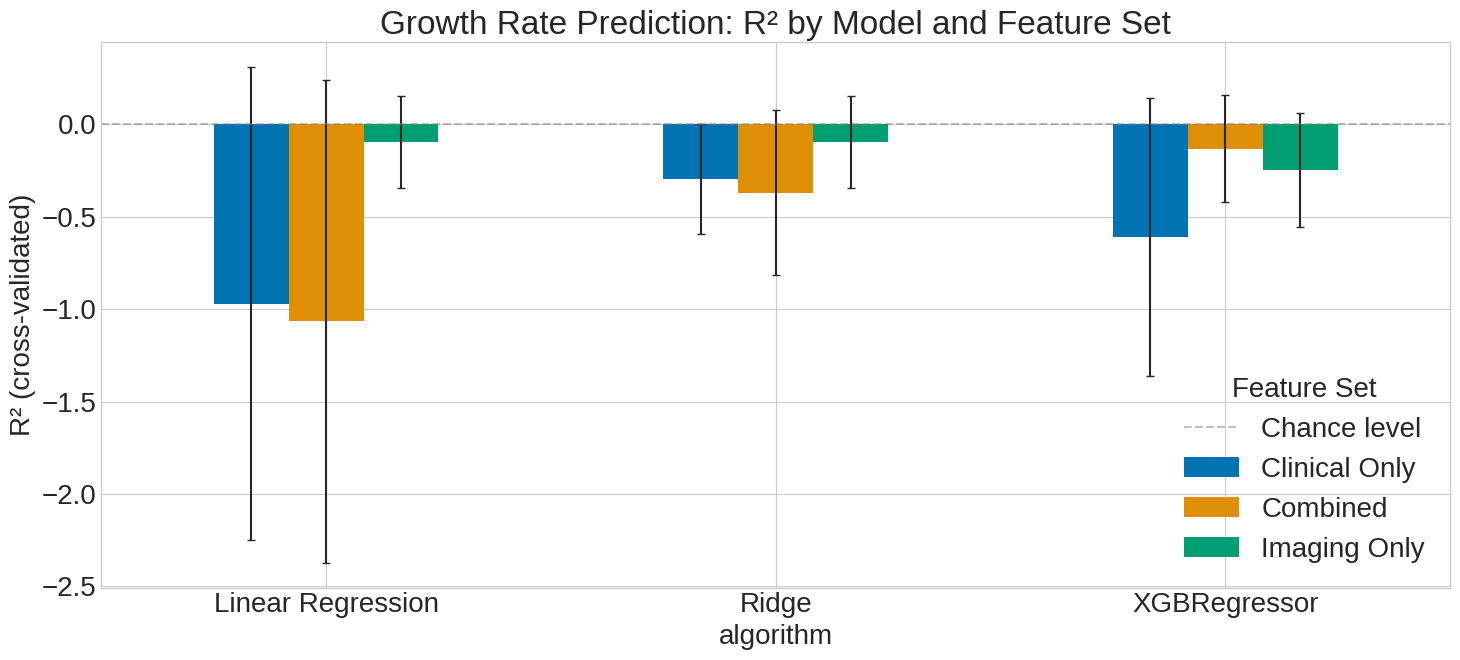

In [28]:
# Visualise: grouped bar chart of R² by model and feature set
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(15, 7))

pivot = results_df.pivot(index='algorithm', columns='feature_set', values='R2_mean')
pivot_err = results_df.pivot(index='algorithm', columns='feature_set', values='R2_std')

pivot.plot(kind='bar', yerr=pivot_err, ax=ax, capsize=3)
ax.set_ylabel('R² (cross-validated)')
ax.set_title('Growth Rate Prediction: R² by Model and Feature Set')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.axhline(y=0, color='grey', linestyle='--', alpha=0.5, label='Chance level')
ax.legend(title='Feature Set')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_growth_r2_comparison.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, '05_growth_r2_comparison.pdf'), bbox_inches='tight')
plt.show()

## Feature Importance (Best Model)

We inspect which features drive the growth rate prediction in the best-performing model.

In [29]:
# Identify best model configuration
best_idx = results_df['R2_mean'].idxmax()
best_row = results_df.iloc[best_idx]
print(f"Best model: {best_row['model']}")
print(f"  R² = {best_row['R2_mean']:.3f} ± {best_row['R2_std']:.3f}")
print(f"  MAE = {best_row['MAE_mean']:.0f} ± {best_row['MAE_std']:.0f} mm³")

Best model: Ridge (Imaging Only)
  R² = -0.093 ± 0.250
  MAE = 50033 ± 7629 mm³


In [30]:
# Train the best XGBRegressor on full data for feature importance
best_feat_set = best_row['feature_set']
X_best_raw = feature_sets[best_feat_set].copy()

# Apply the same preprocessing as in run_models
categorical_cols = X_best_raw.select_dtypes(include='object').columns
if len(categorical_cols) > 0:
    X_best_encoded = pd.get_dummies(X_best_raw, columns=categorical_cols, drop_first=True)
else:
    X_best_encoded = X_best_raw.copy()

# Handle remaining missing values (for numerical features) by filling with median
X_best = X_best_encoded.fillna(X_best_encoded.median())

# Ensure all column names are strings for XGBoost compatibility
X_best.columns = X_best.columns.astype(str)

xgb_final = XGBRegressor(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
xgb_final.fit(X_best, y_growth_clipped)

# Feature importance
importance = pd.Series(xgb_final.feature_importances_, index=X_best.columns)
importance = importance.sort_values(ascending=False)

print(f"\nTop 15 features for growth rate prediction ({best_feat_set}):")
print("-" * 70)
for feat, imp in importance.head(15).items():
    print(f"  {feat:<61} {imp:.4f}")


Top 15 features for growth rate prediction (Imaging Only):
----------------------------------------------------------------------
  t0_edema_vol                                                  0.1845
  t0_t2f_mean                                                   0.1119
  t0_t2w_mean                                                   0.0879
  t0_t1n_std                                                    0.0817
  t0_t2w_std                                                    0.0755
  vol_t0                                                        0.0724
  t0_cavity_vol                                                 0.0679
  t0_enhancing_vol                                              0.0677
  t0_t2f_std                                                    0.0531
  t0_necrotic_vol                                               0.0525
  t0_t1c_std                                                    0.0503
  t0_t1n_mean                                                   0.0490
  t0_t1c_mean    

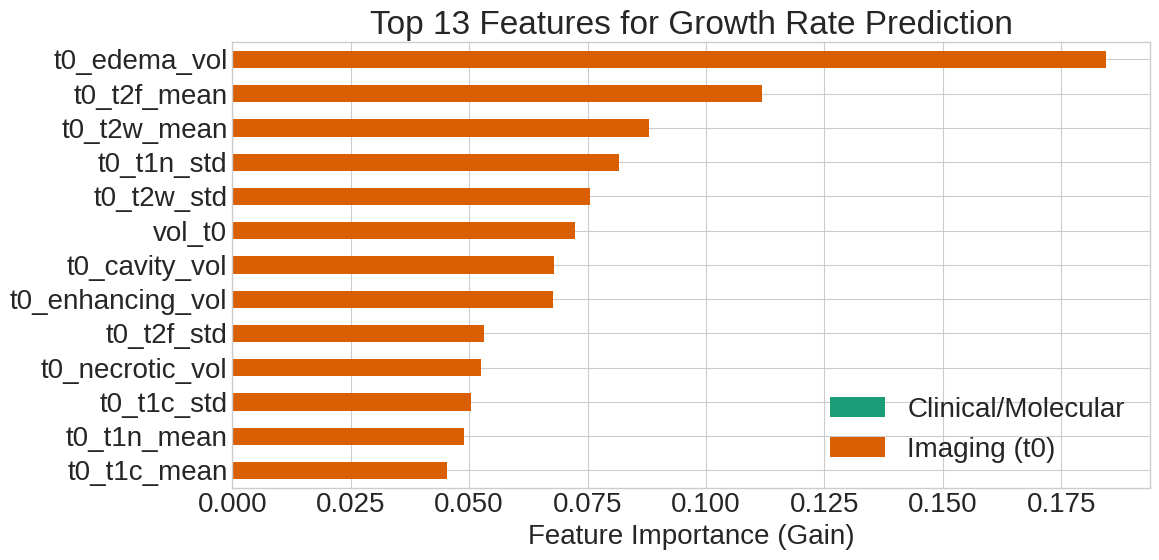

In [31]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(12, 6))

top_n = min(15, len(importance))
top_feats = importance.head(top_n)

# Colour imaging vs clinical features differently
colours = ['#d95f02' if f in imaging_feature_cols else '#1b9e77' for f in top_feats.index]

top_feats.plot(kind='barh', ax=ax, color=colours)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title(f'Top {top_n} Features for Growth Rate Prediction')
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1b9e77', label='Clinical/Molecular'),
    Patch(facecolor='#d95f02', label='Imaging (t0)')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_growth_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, '05_growth_feature_importance.pdf'), bbox_inches='tight')
plt.show()

## Biological Validation: Growth Rate vs Survival

If our predicted growth rates are biologically meaningful, patients with faster-growing tumours should have worse survival outcomes. We stratify patients into growth tertiles and compare their survival status as a sanity check.

In [32]:
# Merge survival outcome with growth data
# The original 'y' series has numerical index, while growth_with_clinical has 'Patient ID'.
# We need to map Patient IDs from original_clinical to the 'death' values from y.
survival_lookup = pd.Series(y.values, index=original_clinical['Patient_ID']).to_dict()

growth_with_clinical['death'] = growth_with_clinical['Patient ID'].map(survival_lookup)

# Check alignment
print(f"Patients with survival data: {growth_with_clinical['death'].notna().sum()} / {len(growth_with_clinical)}")

Patients with survival data: 105 / 105


In [33]:
# Stratify into growth tertiles
growth_with_clinical['growth_tertile'] = pd.qcut(
    growth_with_clinical[TARGET_COL], q=3,
    labels=['Slow/Shrinking', 'Moderate', 'Fast Growing']
)

# Mortality rate per tertile
tertile_mortality = growth_with_clinical.groupby('growth_tertile')['death'].agg(['mean', 'count'])
tertile_mortality.columns = ['Mortality Rate', 'N']
print("Mortality Rate by Growth Tertile:")
print("-" * 45)
for idx, row in tertile_mortality.iterrows():
    print(f"  {idx:<20} {row['Mortality Rate']:.1%}  (n={row['N']:.0f})")

Mortality Rate by Growth Tertile:
---------------------------------------------
  Slow/Shrinking       68.6%  (n=35)
  Moderate             60.0%  (n=35)
  Fast Growing         62.9%  (n=35)


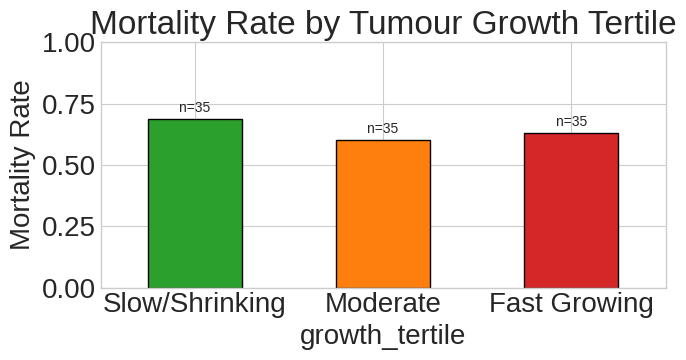


Chi-squared test: χ² = 0.58, p = 0.7492
No significant association detected (may be underpowered with small n).


In [34]:
# Visualise
fig, ax = plt.subplots(figsize=(7, 4))

tertile_mortality['Mortality Rate'].plot(
    kind='bar', ax=ax, color=['#2ca02c', '#ff7f0e', '#d62728'], edgecolor='black'
)
ax.set_ylabel('Mortality Rate')
ax.set_title('Mortality Rate by Tumour Growth Tertile')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 1)

# Add count labels
for i, (idx, row) in enumerate(tertile_mortality.iterrows()):
    ax.text(i, row['Mortality Rate'] + 0.03, f"n={row['N']:.0f}",
            ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_growth_vs_mortality.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, '05_growth_vs_mortality.pdf'), bbox_inches='tight')
plt.show()

# Chi-squared test
contingency = pd.crosstab(growth_with_clinical['growth_tertile'], growth_with_clinical['death'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-squared test: χ² = {chi2:.2f}, p = {p_val:.4f}")
if p_val < 0.05:
    print("Significant association between growth tertile and mortality.")
else:
    print("No significant association detected (may be underpowered with small n).")

## Save Results

In [35]:
# Save results table
results_df.to_csv(os.path.join(RESULTS_DIR, '05_growth_rate_model_comparison.csv'), index=False)

# Save feature importance
importance.to_csv(os.path.join(RESULTS_DIR, '05_growth_rate_feature_importance.csv'))

# Save the growth data for potential reuse
growth_with_clinical.to_csv(os.path.join(RESULTS_DIR, '05_growth_data_with_features.csv'), index=False)

print(f"Results saved to {RESULTS_DIR}")
print(f"Figures saved to {FIGURES_DIR}")

Results saved to drive/MyDrive/Y3 Project/Data/PKG_MU_Glioma_Post/growth_rate/data
Figures saved to drive/MyDrive/Y3 Project/Data/PKG_MU_Glioma_Post/growth_rate/figures


## Summary

This notebook addressed Aim 2 by predicting tumour volume change between consecutive MRI scans using baseline features.

**Key findings** (to be filled after running):
- Best model and feature set: ...
- R² score: ... (compare to 0 baseline; R² > 0 means better than predicting the mean)
- Whether imaging features from the first timepoint add predictive value beyond clinical/molecular markers
- Whether predicted growth rate correlates with actual survival outcomes (biological validation)

**Limitations:**
- Small sample size (~82 patients with 2+ timepoints); results may have high variance
- Volume change used as proxy for growth rate (exact scan dates not available in the segmentation file)
- Pre-computed imaging features are first-order statistics only; texture and shape features (via PyRadiomics) could potentially add value
- Temporal leakage risk is low here since we predict future volume change from baseline features, but growth may correlate with follow-up duration